# GNN –v4 


## 00 – Imports & Reproduzierbarkeit

In [ ]:
%matplotlib inline

import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATv2Conv, BatchNorm, global_mean_pool

from sklearn.metrics import r2_score, mean_absolute_error

from gnn_tools.preprocessing import GrainsToGraph

def seed_everything(seed: int = 42):
    """Setzt alle Zufallsgeneratoren für Reproduzierbarkeit."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Seed gesetzt: 42
Device: cpu


## 01 – Pfade konfigurieren

In [ ]:
CSV_PATH = Path('/Users/anasshbat/Desktop/Uni-mac/Winter26/Projeckt_GNN/gnn_uni/data/00_R_tot_for_Grains_and_Rho_Ratio.csv')
GRIDS_FOLDER = Path('/Users/anasshbat/Desktop/Uni-mac/Winter26/Projeckt_GNN/gnn_uni/data/00_grids')

assert CSV_PATH.exists(), f'CSV nicht gefunden: {CSV_PATH}'
assert GRIDS_FOLDER.exists(), f'Grid-Ordner nicht gefunden: {GRIDS_FOLDER}'

Pfade OK


## 02 – Daten laden & aufbereiten

In [ ]:
df_raw = pd.read_csv(CSV_PATH, comment='#', header=0)
rho_ratios = df_raw.columns[1:].astype(float)

all_data = []
for _, row in df_raw.iterrows():
    grain = row['Grains']
    for rho, val in zip(rho_ratios, row[1:].values):
        all_data.append({'grains': grain, 'leitfaehigkeit': rho, 'widerstand': val})

df_R = pd.DataFrame(all_data)
df_R.head()

Datensatz: 57660 Zeilen
   grains  leitfaehigkeit    widerstand
0    16.0            1.00  10000.233814
1    16.0            1.26  10000.295718
2    16.0            1.60  10000.373979
3    16.0            2.02  10000.472937
4    16.0            2.56  10000.598052


In [ ]:
grain_to_file_map = {}
for f in GRIDS_FOLDER.glob('*.npz'):
    match = re.search(r'grains_(\d+)', f.name)
    if match:
        grain_to_file_map[int(match.group(1))] = f

len(grain_to_file_map)

930 Grid-Dateien gefunden.


## 03 – Konfiguration (ExperimentConfig)

In [ ]:
from dataclasses import dataclass

@dataclass
class ExperimentConfig:
    epochs: int = 50
    batch_size: int = 32
    lr: float = 1e-3

    node_features: int = 4
    edge_features: int = 2
    hidden_dim: int = 128
    dropout: float = 0.2

    max_grains: int = 500
    use_all_conds: bool = True
    targets: tuple = (1e2, 1e3, 1e4, 1e5)

    train_frac: float = 0.70
    val_frac: float = 0.15

    seed: int = 42
    experiment_name: str = 'exp_optimized'

CFG = ExperimentConfig()
CFG

ExperimentConfig(epochs=50, batch_size=32, lr=0.001, node_features=4, edge_features=2, hidden_dim=128, dropout=0.2, max_grains=500, use_all_conds=True, targets=(100.0, 1000.0, 10000.0, 100000.0), train_frac=0.7, val_frac=0.15, seed=42, experiment_name='exp_optimized')


## 04 – Normalisierung

In [ ]:
from dataclasses import dataclass as _dc, field as _field

@_dc
class FeatureStats:
    """Min-Max-Statistiken für Knoten-, Kantenfeatures und globales u."""
    node_min: np.ndarray = _field(default=None)
    node_max: np.ndarray = _field(default=None)
    edge_min: np.ndarray = _field(default=None)
    edge_max: np.ndarray = _field(default=None)
    u_min: float = 0.0
    u_max: float = 1.0

    def transform_nodes(self, x: np.ndarray) -> np.ndarray:
        denom = self.node_max - self.node_min
        denom = np.where(denom == 0, 1.0, denom)
        return (x - self.node_min) / denom

    def transform_edges(self, ea: np.ndarray) -> np.ndarray:
        denom = self.edge_max - self.edge_min
        denom = np.where(denom == 0, 1.0, denom)
        return (ea - self.edge_min) / denom

    def transform_u(self, u_val: float) -> float:
        denom = self.u_max - self.u_min
        if denom == 0:
            return 0.0
        return (u_val - self.u_min) / denom

def fit_normalizer(train_df: pd.DataFrame, grain_mapping: dict) -> FeatureStats:
    """Fittet Normalisierungsstatistiken ausschließlich auf dem Trainingssplit."""
    all_node_feats = []
    all_edge_feats = []

    seen_grains = set()
    for grain_count in train_df['grains'].astype(int).unique():
        if grain_count not in grain_mapping or grain_count in seen_grains:
            continue
        seen_grains.add(grain_count)

        g2g = GrainsToGraph(filepath=grain_mapping[grain_count])
        node_info = g2g.node_information(as_frame=True)
        edge_info = g2g.edge_information(as_frame=True)

        all_node_feats.append(
            node_info[['volume', 'center-coord-0', 'center-coord-1', 'center-coord-2']].values.astype(np.float32)
        )
        all_edge_feats.append(
            edge_info[['contact_area', 'distance']].values.astype(np.float32)
        )

    all_nodes = np.concatenate(all_node_feats, axis=0)
    all_edges = np.concatenate(all_edge_feats, axis=0)

    return FeatureStats(
        node_min=all_nodes.min(axis=0),
        node_max=all_nodes.max(axis=0),
        edge_min=all_edges.min(axis=0),
        edge_max=all_edges.max(axis=0),
        u_min=float(train_df['u_log'].min()),
        u_max=float(train_df['u_log'].max()),
    )

## 05 – Dataset & DataLoader

In [ ]:
def filter_leitfaehigkeit(df: pd.DataFrame, targets) -> pd.DataFrame:
    """Wählt je Zielwert den nächstliegenden vorhandenen Leitfähigkeitswert."""
    unique = df['leitfaehigkeit'].unique()
    selected = [unique[np.abs(unique - t).argmin()] for t in targets]
    return df[df['leitfaehigkeit'].isin(selected)].copy()

class SparseGrainDataset(Dataset):
    """Lazy-loading Dataset mit Caching roher Geometrie und normierten Features."""

    def __init__(self, df: pd.DataFrame, grain_mapping: dict, stats: FeatureStats):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.grain_mapping = grain_mapping
        self.stats = stats
        self._raw_cache = {}

    def len(self):
        return len(self.df)

    def __len__(self):
        return self.len()

    def get(self, idx):
        row = self.df.iloc[idx]
        grain_count = int(row['grains'])

        if grain_count not in self.grain_mapping:
            raise KeyError(f'Kein Grid für grains={grain_count}')

        fp = self.grain_mapping[grain_count]
        if fp not in self._raw_cache:
            g2g = GrainsToGraph(filepath=fp)
            node_info = g2g.node_information(as_frame=True)
            edge_info = g2g.edge_information(as_frame=True)

            raw_nodes = node_info[['volume', 'center-coord-0', 'center-coord-1', 'center-coord-2']].values.astype(np.float32)
            raw_edges = edge_info[['contact_area', 'distance']].values.astype(np.float32)
            edge_idx = torch.tensor(
                edge_info[['center_node', 'neighbor_node']].values.T,
                dtype=torch.long,
            )
            self._raw_cache[fp] = (raw_nodes, raw_edges, edge_idx)

        raw_nodes, raw_edges, edge_idx = self._raw_cache[fp]
        norm_nodes = self.stats.transform_nodes(raw_nodes)
        norm_edges = self.stats.transform_edges(raw_edges)
        u_norm = self.stats.transform_u(float(row['u_log']))

        return Data(
            x=torch.tensor(norm_nodes, dtype=torch.float),
            edge_index=edge_idx,
            edge_attr=torch.tensor(norm_edges, dtype=torch.float),
            y=torch.tensor([row['y_log']], dtype=torch.float),
            u=torch.tensor([u_norm], dtype=torch.float),
        )

def prepare_dataframe(cfg: ExperimentConfig) -> pd.DataFrame:
    df = df_R.copy()

    if not cfg.use_all_conds:
        df = filter_leitfaehigkeit(df, cfg.targets)

    df = df[df['grains'] <= cfg.max_grains].copy()

    available = set(grain_to_file_map.keys())
    df = df[df['grains'].astype(int).isin(available)].copy()

    if df.empty:
        raise ValueError('Keine Daten nach dem Filter übrig!')

    df['u_log'] = np.log10(df['leitfaehigkeit'])
    df['y_log'] = np.log10(df['widerstand'])
    return df

def build_dataset_and_loaders(cfg: ExperimentConfig):
    df = prepare_dataframe(cfg)

    rng = np.random.default_rng(cfg.seed)
    idx = rng.permutation(len(df))
    n_tr = int(cfg.train_frac * len(df))
    n_val = int(cfg.val_frac * len(df))

    train_df = df.iloc[idx[:n_tr]].copy()
    val_df = df.iloc[idx[n_tr:n_tr + n_val]].copy()
    test_df = df.iloc[idx[n_tr + n_val:]].copy()

    # Fit nur auf Training verhindert Data Leakage.
    stats = fit_normalizer(train_df, grain_to_file_map)

    train_ds = SparseGrainDataset(train_df, grain_to_file_map, stats)
    val_ds = SparseGrainDataset(val_df, grain_to_file_map, stats)
    test_ds = SparseGrainDataset(test_df, grain_to_file_map, stats)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, stats

## 05 – Modell (GATv2)

In [8]:
class GrainGNN(nn.Module):
    """
    Graph Attention Network (GATv2) zur Vorhersage des Kornwiderstands.

    Architektur:
      - 2x GATv2Conv mit BatchNorm + ReLU
      - Global Mean Pooling
      - Konkatenation mit globalem Parameter u (log Leitfähigkeit)
      - 2-schichtiger MLP mit Dropout
    """

    def __init__(self, node_features: int = 4, edge_features: int = 2,
                 h_fea_len: int = 128, dropout: float = 0.2):
        super().__init__()

        self.conv1 = GATv2Conv(node_features, 64, edge_dim=edge_features)
        self.bn1   = BatchNorm(64)
        self.conv2 = GATv2Conv(64, 64, edge_dim=edge_features)
        self.bn2   = BatchNorm(64)

        self.fc = nn.Sequential(
            nn.Linear(64 + 1, h_fea_len),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h_fea_len, 1)
        )

    def forward(self, data):
        x, ei, ea, batch, u = (
            data.x, data.edge_index, data.edge_attr, data.batch, data.u)

        x = F.relu(self.bn1(self.conv1(x, ei, ea)))
        x = F.relu(self.bn2(self.conv2(x, ei, ea)))
        x = global_mean_pool(x, batch)

        if u.dim() == 1:
            u = u.view(-1, 1)

        return self.fc(torch.cat([x, u], dim=1))

## 06 – Training & Evaluation

In [9]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch), batch.y.view(-1, 1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for batch in loader:
        batch = batch.to(device)
        loss = criterion(model(batch), batch.y.view(-1, 1))
        total_loss += loss.item() * batch.num_graphs
    return total_loss / len(loader.dataset)


def train_model(model, train_loader, val_loader, cfg: ExperimentConfig):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    criterion = nn.MSELoss()
    history   = {'train': [], 'val': []}

    for epoch in range(cfg.epochs):
        tr_loss  = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = eval_one_epoch(model, val_loader, criterion)

        history['train'].append(tr_loss)
        history['val'].append(val_loss)

        if epoch % 10 == 0 or epoch == cfg.epochs - 1:
            print(f'Epoch {epoch:03d}/{cfg.epochs} | '
                  f'Train MSE: {tr_loss:.5f} | Val MSE: {val_loss:.5f}')

    return history


@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for batch in loader:
        batch = batch.to(device)
        y_true.append(batch.y.cpu().numpy())
        y_pred.append(model(batch).cpu().numpy())
    return np.concatenate(y_true).ravel(), np.concatenate(y_pred).ravel()


def print_metrics(y_true_log, y_pred_log, split='Test'):
    y_true_real = 10 ** y_true_log
    y_pred_real = 10 ** y_pred_log

    print(f'\n===== {split} – Log Space =====')
    print(f'  MAE  : {mean_absolute_error(y_true_log, y_pred_log):.6f}')
    print(f'  MAPE : {np.mean(np.abs((y_true_log - y_pred_log)/y_true_log))*100:.4f} %')
    print(f'  R²   : {r2_score(y_true_log, y_pred_log):.6f}')

    print(f'\n===== {split} – Real Space =====')
    print(f'  MAE  : {mean_absolute_error(y_true_real, y_pred_real):.4f}')
    print(f'  MAPE : {np.mean(np.abs((y_true_real - y_pred_real)/y_true_real))*100:.4f} %')
    print(f'  R²   : {r2_score(y_true_real, y_pred_real):.6f}')

## 07 – Visualisierung

In [ ]:
def plot_history(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history['train'], label='Train Loss')
    plt.plot(history['val'], label='Val Loss')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_parity(y_true_log, y_pred_log, title='Parity Plot (Log Space)'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    ax = axes[0]
    ax.scatter(y_true_log, y_pred_log, alpha=0.4, s=10)
    mn, mx = min(y_true_log.min(), y_pred_log.min()), max(y_true_log.max(), y_pred_log.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_xlabel('True log10(R)')
    ax.set_ylabel('Pred log10(R)')
    ax.set_title('Parity Plot - Log Space')
    ax.grid(True)

    y_true_real = 10 ** y_true_log
    y_pred_real = 10 ** y_pred_log
    ax = axes[1]
    ax.scatter(y_true_real, y_pred_real, alpha=0.4, s=10)
    mn, mx = min(y_true_real.min(), y_pred_real.min()), max(y_true_real.max(), y_pred_real.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('True R (Ohm)')
    ax.set_ylabel('Pred R (Ohm)')
    ax.set_title('Parity Plot - Real Space')
    ax.grid(True)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

## 08 – Experiment speichern

In [ ]:
def save_experiment(model, history, cfg: ExperimentConfig):
    exp_dir = Path('./exps') / cfg.experiment_name
    exp_dir.mkdir(parents=True, exist_ok=True)

    torch.save(model.state_dict(), exp_dir / 'best_model.pth')

    with open(exp_dir / 'config.json', 'w') as f:
        json.dump(cfg.__dict__, f, indent=4)

    pd.DataFrame(history).to_csv(exp_dir / 'training_history.csv', index=False)
    return exp_dir

def load_model(exp_dir: Path, cfg: ExperimentConfig) -> GrainGNN:
    m = GrainGNN(
        node_features=cfg.node_features,
        edge_features=cfg.edge_features,
        h_fea_len=cfg.hidden_dim,
        dropout=cfg.dropout,
    ).to(device)
    m.load_state_dict(torch.load(exp_dir / 'best_model.pth', map_location=device))
    return m

## 09 – Hauptprogramm ausführen

In [ ]:
CFG = ExperimentConfig(
    epochs=200,
    batch_size=32,
    lr=1e-3,
    hidden_dim=128,
    dropout=0.2,
    max_grains=500,
    use_all_conds=True,
    seed=42,
    experiment_name='exp_optimized_2',
)

seed_everything(CFG.seed)

train_loader, val_loader, test_loader, stats = build_dataset_and_loaders(CFG)

model = GrainGNN(
    node_features=CFG.node_features,
    edge_features=CFG.edge_features,
    h_fea_len=CFG.hidden_dim,
    dropout=CFG.dropout,
).to(device)

history = train_model(model, train_loader, val_loader, CFG)
exp_dir = save_experiment(model, history, CFG)

Seed gesetzt: 42
Datensatz bereit: 9300 Zeilen  |  Grains: 16–500  |  Leitfähigkeiten: 62
Split → Train: 6510  Val: 1395  Test: 1395
Normalisierungsstatistiken werden berechnet (nur Trainingsdaten)...
  Node features  – min: [63.          0.48845166  0.45132744  0.5562914 ]  max: [1.331440e+05 9.927396e+01 9.927924e+01 9.953253e+01]
  Edge features  – min: [1.        3.4806633]  max: [4233.        67.49243]
  u_log          – min: 0.0000  max: 5.0000
Parameter: 18,305
Epoch 000/200 | Train MSE: 1.22267 | Val MSE: 0.01480
Epoch 010/200 | Train MSE: 0.08326 | Val MSE: 0.01101
Epoch 020/200 | Train MSE: 0.07117 | Val MSE: 0.02714
Epoch 030/200 | Train MSE: 0.05917 | Val MSE: 0.01226
Epoch 040/200 | Train MSE: 0.04745 | Val MSE: 0.01852
Epoch 050/200 | Train MSE: 0.03714 | Val MSE: 0.00992
Epoch 060/200 | Train MSE: 0.02824 | Val MSE: 0.00945
Epoch 070/200 | Train MSE: 0.02279 | Val MSE: 0.00987
Epoch 080/200 | Train MSE: 0.01796 | Val MSE: 0.00962
Epoch 090/200 | Train MSE: 0.01481 | Val 

## 10 – Ergebnisse auswerten

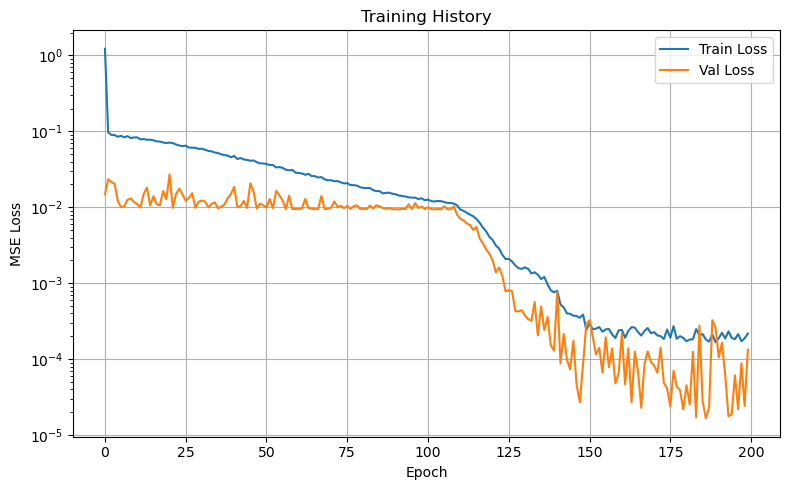


===== Validation – Log Space =====
  MAE  : 0.006637
  MAPE : 0.1570 %
  R²   : 0.993477

===== Validation – Real Space =====
  MAE  : 291.1795
  MAPE : 1.5643 %
  R²   : 0.991469


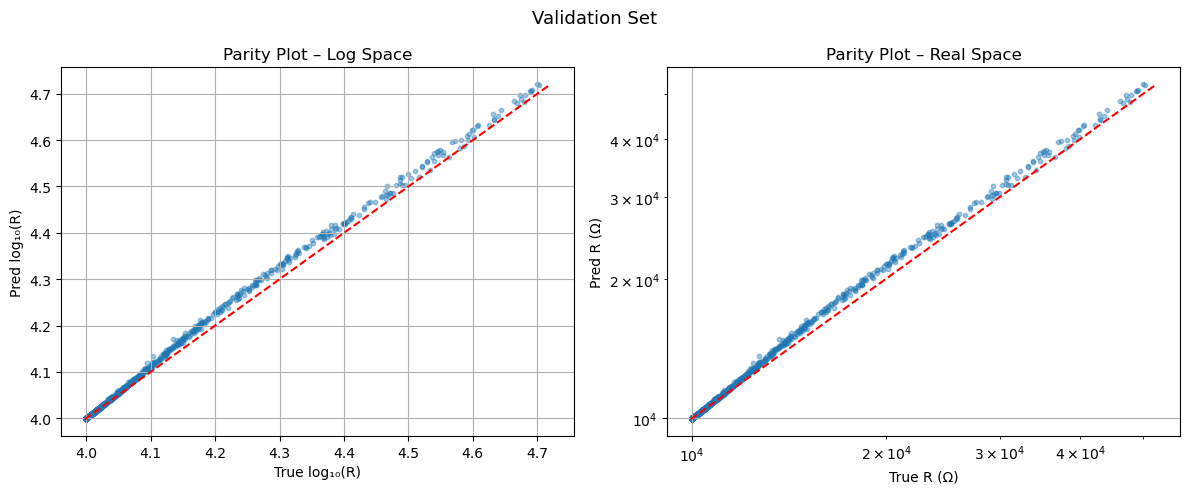


===== Test – Log Space =====
  MAE  : 0.006333
  MAPE : 0.1499 %
  R²   : 0.993278

===== Test – Real Space =====
  MAE  : 276.7333
  MAPE : 1.4932 %
  R²   : 0.990843


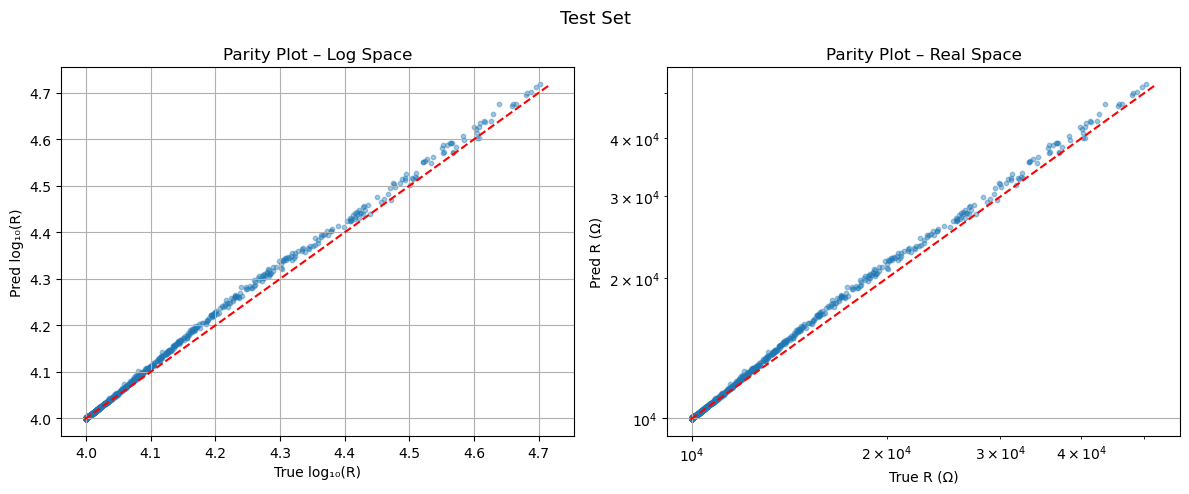

In [ ]:
plot_history(history)

y_true_val, y_pred_val = get_predictions(model, val_loader)
print_metrics(y_true_val, y_pred_val, split='Validation')
plot_parity(y_true_val, y_pred_val, title='Validation Set')

y_true_test, y_pred_test = get_predictions(model, test_loader)
print_metrics(y_true_test, y_pred_test, split='Test')
plot_parity(y_true_test, y_pred_test, title='Test Set')

## 11 – (Optional) Modell erneut laden & auswerten
Führe diese Zelle aus, um ein gespeichertes Modell zu laden, ohne neu zu trainieren.

In [3]:
model_loaded = load_model(Path('gnn_uni/exps/exp_model_all_leitfaehigkeit&200_Epoch'), CFG)
y_true, y_pred = get_predictions(model_loaded, test_loader)
print_metrics(y_true, y_pred, split='Test (loaded)')
plot_parity(y_true, y_pred)

NameError: name 'load_model' is not defined